In [1]:
import time
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np


In [2]:
from utils import tour_length, plot_tsp_route
from NN_alg import nearest_neighbor
from ACO_alg import ant_colony_optimization, calculate_tour_length

In [3]:
datasets = {
    "N=20": pd.read_csv("data/dist_df_20.csv"),
    "N=50": pd.read_csv("data/dist_df_50.csv"),
    "N=100": pd.read_csv("data/dist_df_100.csv"),
}

### Eksperymenty wstępne
W pierwszym etapie sprawdzono kilka szeroko różniących się konfiguracji ACO, aby określić, które zakresy hiperparametrów dają najlepsze wyniki.



In [4]:
params = [
    {
        "label": "ACO mniej mrówek",
        "alpha": 1.0,
        "beta": 5.0,
        "rho": 0.05,
        "q": 10.0,
        "initial_pheromone": 0.1,
        "n_ants": 20,
        "n_iterations": 500
    },
    {
        "label": "ACO niskie Beta",
        "alpha": 1.0,
        "beta": 2.0,
        "rho": 0.10,
        "q": 10.0,
        "initial_pheromone": 0.1,
        "n_ants": 50,
        "n_iterations": 100
    },
    {
        "label": "ACO zbalansowane",
        "alpha": 1.0,
        "beta": 4.0,
        "rho": 0.05,
        "q": 10.0,
        "initial_pheromone": 0.1,
        "n_ants": 50,
        "n_iterations": 250
    },
    {
        "label": "ACO wysokie Beta",
        "alpha": 1.0,
        "beta": 7.0,
        "rho": 0.05,
        "q": 10.0,
        "initial_pheromone": 0.1,
        "n_ants": 50,
        "n_iterations": 250
    },
    {
        "label": "ACO więcej iteracji",
        "alpha": 1.0,
        "beta": 5.0,
        "rho": 0.05,
        "q": 10.0,
        "initial_pheromone": 0.1,
        "n_ants": 50,
        "n_iterations": 500
    },
    {
        "label": "ACO więcej mrówek",
        "alpha": 1.0,
        "beta": 5.0,
        "rho": 0.05,
        "q": 10.0,
        "initial_pheromone": 0.1,
        "n_ants": 80,
        "n_iterations": 250
    },
    {
        "label": "ACO większy wpływ feromonu",
        "alpha": 2.0,
        "beta": 5.0,
        "rho": 0.05,
        "q": 10.0,
        "initial_pheromone": 0.1,
        "n_ants": 80,
        "n_iterations": 500
    },
    {
        "label": "ACO wolniejsze parowanie",
        "alpha": 2.0,
        "beta": 5.0,
        "rho": 0.03,
        "q": 10.0,
        "initial_pheromone": 0.1,
        "n_ants": 80,
        "n_iterations": 500
    }
]

#### Petla eksperymentalna

In [5]:
all_results = []
convergence_data = {}
best_aco_routes = {}
for ds_name, dist_df in datasets.items():
    print(f"Uruchamianie eksperymentów dla zbioru {ds_name}...")
    
    dist_matrix = dist_df.to_numpy(dtype=float)

    convergence_data[ds_name] = {}
    best_dist_in_ds = float('inf')
    # Nearest Neighbor (punkt odniesienia) 
    start_time = time.time()
    nn_route = nearest_neighbor(dist_matrix) 
    nn_time = time.time() - start_time
    nn_dist = calculate_tour_length(nn_route, dist_matrix)
    
    all_results.append({
        "Rozmiar danych": ds_name,
        "Algorytm / Konfiguracja": "Nearest Neighbor",
        "Hiperparametry": "Brak (Heurystyka)",
        "Długość trasy (km)": round(nn_dist, 2),
        "Czas wykonania (s)": round(nn_time, 4)
    })
    
    # eksperymenty ACO 
    for par in params:
        start_time = time.time()
        
        best_tour, best_length, history = ant_colony_optimization(
            dist_matrix=dist_matrix,
            n_ants=par["n_ants"],
            n_iterations=par["n_iterations"],
            alpha=par["alpha"],
            beta=par["beta"],
            rho=par["rho"],
            q=par["q"],
            initial_pheromone=par["initial_pheromone"],
            start_city=None
        )
        
        exec_time = time.time() - start_time
        
        all_results.append({
            "Rozmiar danych": ds_name,
            "Algorytm / Konfiguracja": par["label"],
            "Hiperparametry": f"alfa={par['alpha']}, beta={par['beta']}, rho={par['rho']}, mrówek={par['n_ants']}, iteracji={par['n_iterations']}",
            "Długość trasy (km)": round(best_length, 2),
            "Czas wykonania (s)": round(exec_time, 4)
        })
        
        convergence_data[ds_name][par["label"]] = history
        
        # najlepsza trasa dla danego zbioru
        if best_length < best_dist_in_ds:
            best_dist_in_ds = best_length
            best_aco_routes[ds_name] = best_tour

Uruchamianie eksperymentów dla zbioru N=20...
Uruchamianie eksperymentów dla zbioru N=50...
Uruchamianie eksperymentów dla zbioru N=100...


#### Tabela porównawcza

In [6]:
summary_df = pd.DataFrame(all_results)
print("\n" + "="*80)
print(" TABELA PORÓWNAWCZA WYNIKÓW ")
print("="*80)
display(summary_df)


 TABELA PORÓWNAWCZA WYNIKÓW 


,Rozmiar danych,Algorytm / Konfiguracja,Hiperparametry,Długość trasy (km),Czas wykonania (s)
0,N=20,Nearest Neighbor,Brak (Heurystyka),2294.34,0.0001
1,N=20,ACO mniej mrówek,"alfa=1.0, beta=5.0, rho=0.05, mrówek=20, itera...",2077.58,2.4492
2,N=20,ACO niskie Beta,"alfa=1.0, beta=2.0, rho=0.1, mrówek=50, iterac...",2077.58,1.1504
3,N=20,ACO zbalansowane,"alfa=1.0, beta=4.0, rho=0.05, mrówek=50, itera...",2077.58,2.9244
4,N=20,ACO wysokie Beta,"alfa=1.0, beta=7.0, rho=0.05, mrówek=50, itera...",2077.58,2.9023
5,N=20,ACO więcej iteracji,"alfa=1.0, beta=5.0, rho=0.05, mrówek=50, itera...",2077.58,5.8037
6,N=20,ACO więcej mrówek,"alfa=1.0, beta=5.0, rho=0.05, mrówek=80, itera...",2077.58,4.7954
7,N=20,ACO większy wpływ feromonu,"alfa=2.0, beta=5.0, rho=0.05, mrówek=80, itera...",2113.29,9.4392
8,N=20,ACO wolniejsze parowanie,"alfa=2.0, beta=5.0, rho=0.03, mrówek=80, itera...",2077.58,9.4430
9,N=50,Nearest Neighbor,Brak (Heurystyka),3542.08,0.0002


#### Wykresy zbieznosci

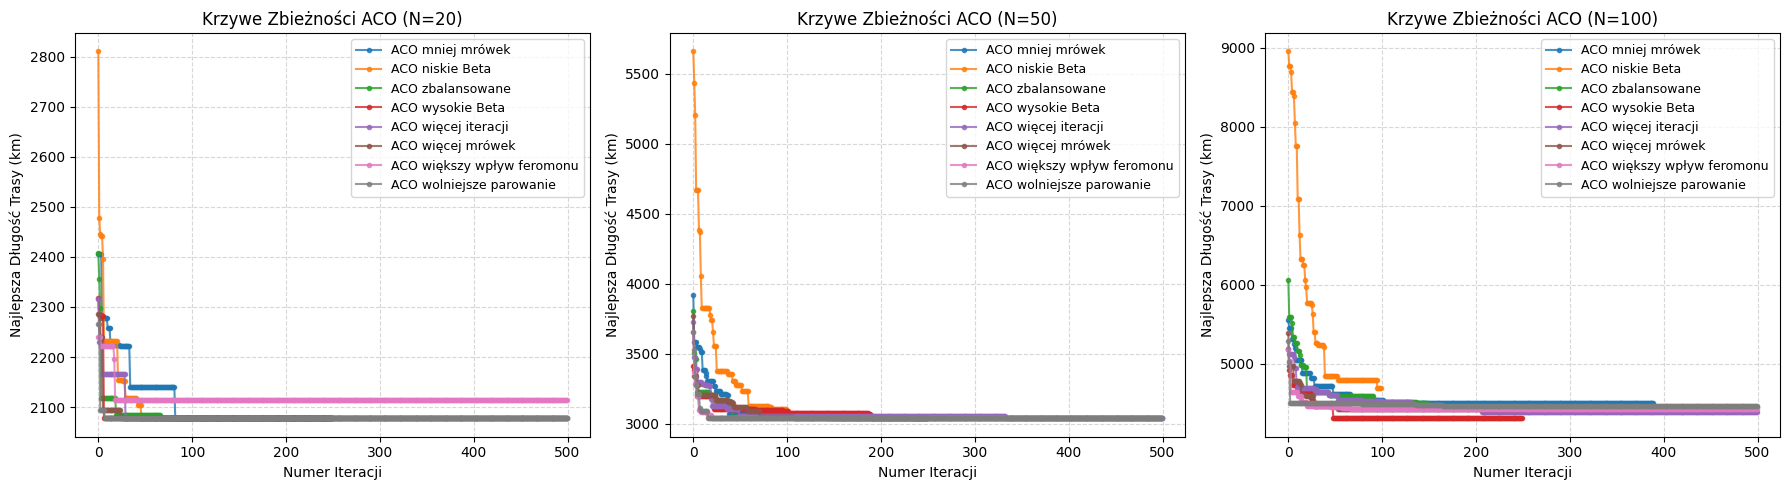

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (ds_name, curves) in enumerate(convergence_data.items()):
    ax = axes[i]
    for label, history in curves.items():
        ax.plot(history, label=label, marker='.', alpha=0.8)
        
    ax.set_title(f"Krzywe Zbieżności ACO ({ds_name})")
    ax.set_xlabel("Numer Iteracji")
    ax.set_ylabel("Najlepsza Długość Trasy (km)")
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

Najlepsze wyniki uzyskano dla konfiguracji z większym wpływem feromonu: alpha=2.0, beta=5.0, rho=0.05. Dlatego w kolejnym etapie wykonano dokładniejszy tuning wokół tych wartości.

### Eksperyment 2
Tuning parametrów wokół najlepszych wariantów:
alpha = 1.0
beta = 4.0 - 6.0
rho = 0.04 - 0.07
n_ants = 80 - 100
n_iterations = 250 - 500

In [8]:
tuning_params = [
    {
        "label": "Tuning A punkt bazowy",
        "alpha": 1.0,
        "beta": 5.0,
        "rho": 0.05,
        "q": 10.0,
        "initial_pheromone": 0.1,
        "n_ants": 80,
        "n_iterations": 250
    },
    {
        "label": "Tuning B więcej iteracji",
        "alpha": 1.0,
        "beta": 5.0,
        "rho": 0.05,
        "q": 10.0,
        "initial_pheromone": 0.1,
        "n_ants": 80,
        "n_iterations": 500
    },
    {
        "label": "Tuning C więcej mrówek",
        "alpha": 1.0,
        "beta": 5.0,
        "rho": 0.05,
        "q": 10.0,
        "initial_pheromone": 0.1,
        "n_ants": 100,
        "n_iterations": 250
    },
    {
        "label": "Tuning D Beta 4",
        "alpha": 1.0,
        "beta": 4.0,
        "rho": 0.05,
        "q": 10.0,
        "initial_pheromone": 0.1,
        "n_ants": 80,
        "n_iterations": 250
    },
    {
        "label": "Tuning E Beta 6",
        "alpha": 1.0,
        "beta": 6.0,
        "rho": 0.05,
        "q": 10.0,
        "initial_pheromone": 0.1,
        "n_ants": 80,
        "n_iterations": 250
    },
    {
        "label": "Tuning F rho 0.04",
        "alpha": 1.0,
        "beta": 5.0,
        "rho": 0.04,
        "q": 10.0,
        "initial_pheromone": 0.1,
        "n_ants": 80,
        "n_iterations": 250
    },
    {
        "label": "Tuning G rho 0.07",
        "alpha": 1.0,
        "beta": 5.0,
        "rho": 0.07,
        "q": 10.0,
        "initial_pheromone": 0.1,
        "n_ants": 80,
        "n_iterations": 250
    },
    {
        "label": "Tuning H alfa 1.5",
        "alpha": 1.5,
        "beta": 5.0,
        "rho": 0.05,
        "q": 10.0,
        "initial_pheromone": 0.1,
        "n_ants": 80,
        "n_iterations": 250
    }
]

#### Petla eksperyment 2

In [9]:
tuning_results = []
tuning_convergence_data = {}
best_tuning_routes = {}
for ds_name, dist_df in datasets.items():
    print(f"Uruchamianie eksperymentu nr 2 dla zbioru {ds_name}...")
    
    dist_matrix = dist_df.to_numpy(dtype=float)
    print(ds_name, dist_matrix.shape)
    print("symmetric:", np.allclose(dist_matrix, dist_matrix.T))
    print("diagonal zero:", np.allclose(np.diag(dist_matrix), 0))

    tuning_convergence_data[ds_name] = {}
    best_dist_in_ds = float('inf')
     
    start_time = time.time()
    nn_route = nearest_neighbor(dist_matrix) 
    nn_time = time.time() - start_time
    nn_dist = calculate_tour_length(nn_route, dist_matrix)
    
    tuning_results.append({
        "Rozmiar danych": ds_name,
        "Algorytm / Konfiguracja": "Nearest Neighbor",
        "Hiperparametry": "Brak (Heurystyka)",
        "Długość trasy (km)": round(nn_dist, 2),
        "Czas wykonania (s)": round(nn_time, 4)
    })
    
     
    for par in tuning_params:
        start_time = time.time()
        
        best_tour, best_length, history = ant_colony_optimization(
            dist_matrix=dist_matrix,
            n_ants=par["n_ants"],
            n_iterations=par["n_iterations"],
            alpha=par["alpha"],
            beta=par["beta"],
            rho=par["rho"],
            q=par["q"],
            initial_pheromone=par["initial_pheromone"],
            start_city=None
        )
        
        exec_time = time.time() - start_time
        
        tuning_results.append({
            "Rozmiar danych": ds_name,
            "Algorytm / Konfiguracja": par["label"],
            "Hiperparametry": f"alfa={par['alpha']}, beta={par['beta']}, rho={par['rho']}, mrówek={par['n_ants']}, iteracji={par['n_iterations']}",
            "Długość trasy (km)": round(best_length, 2),
            "Czas wykonania (s)": round(exec_time, 4)
        })
        
        tuning_convergence_data[ds_name][par["label"]] = history
        
        if best_length < best_dist_in_ds:
            best_dist_in_ds = best_length
            best_tuning_routes[ds_name] = best_tour

Uruchamianie eksperymentu nr 2 dla zbioru N=20...
N=20 (20, 20)
symmetric: True
diagonal zero: True
Uruchamianie eksperymentu nr 2 dla zbioru N=50...
N=50 (50, 50)
symmetric: True
diagonal zero: True
Uruchamianie eksperymentu nr 2 dla zbioru N=100...
N=100 (100, 100)
symmetric: True
diagonal zero: True


In [10]:
summary_df = pd.DataFrame(tuning_results)
print("\n" + "="*80)
print(" TABELA PORÓWNAWCZA WYNIKÓW PO TUNINGU")
print("="*80)
display(summary_df)


 TABELA PORÓWNAWCZA WYNIKÓW PO TUNINGU


,Rozmiar danych,Algorytm / Konfiguracja,Hiperparametry,Długość trasy (km),Czas wykonania (s)
0,N=20,Nearest Neighbor,Brak (Heurystyka),2294.34,0.0001
1,N=20,Tuning A punkt bazowy,"alfa=1.0, beta=5.0, rho=0.05, mrówek=80, itera...",2077.58,4.7067
2,N=20,Tuning B więcej iteracji,"alfa=1.0, beta=5.0, rho=0.05, mrówek=80, itera...",2077.58,9.2671
3,N=20,Tuning C więcej mrówek,"alfa=1.0, beta=5.0, rho=0.05, mrówek=100, iter...",2077.58,5.7754
4,N=20,Tuning D Beta 4,"alfa=1.0, beta=4.0, rho=0.05, mrówek=80, itera...",2077.58,4.6253
5,N=20,Tuning E Beta 6,"alfa=1.0, beta=6.0, rho=0.05, mrówek=80, itera...",2077.58,4.6480
6,N=20,Tuning F rho 0.04,"alfa=1.0, beta=5.0, rho=0.04, mrówek=80, itera...",2077.58,4.6286
7,N=20,Tuning G rho 0.07,"alfa=1.0, beta=5.0, rho=0.07, mrówek=80, itera...",2078.69,5.1269
8,N=20,Tuning H alfa 1.5,"alfa=1.5, beta=5.0, rho=0.05, mrówek=80, itera...",2077.58,4.6468
9,N=50,Nearest Neighbor,Brak (Heurystyka),3542.08,0.0002


#### Wykresy zbieznosci po tuningu

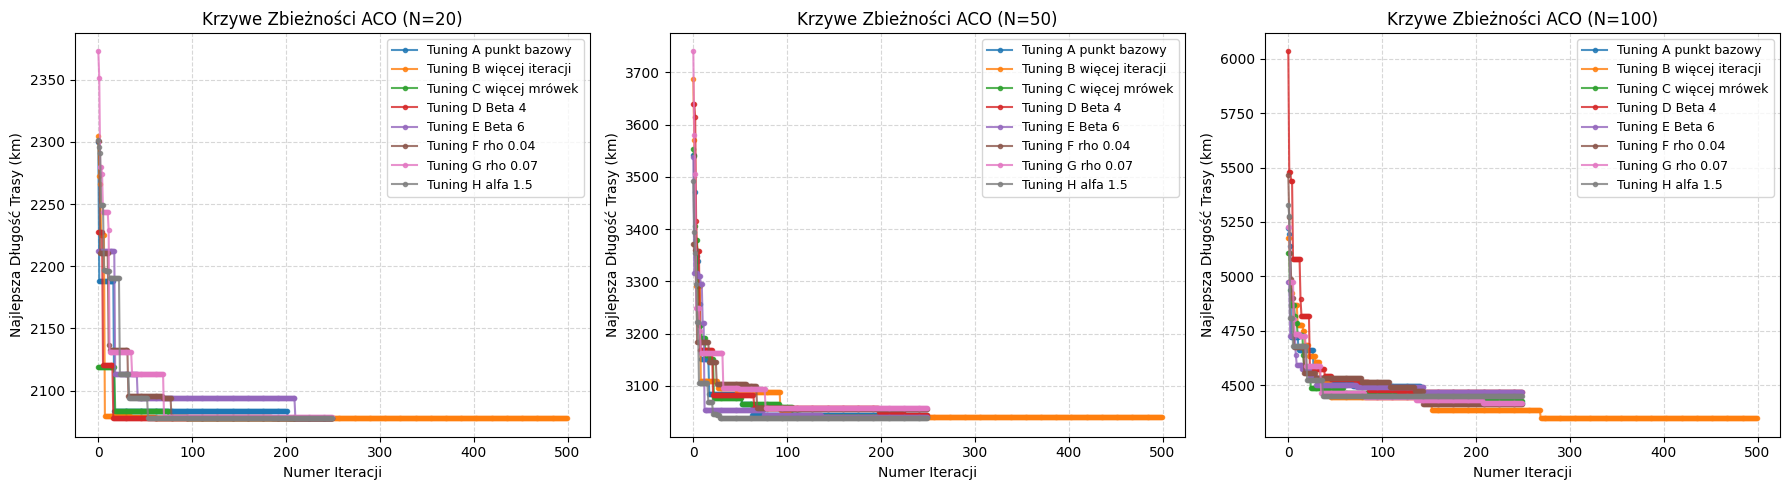

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (ds_name, curves) in enumerate(tuning_convergence_data.items()):
    ax = axes[i]
    for label, history in curves.items():
        ax.plot(history, label=label, marker='.', alpha=0.8)
        
    ax.set_title(f"Krzywe Zbieżności ACO ({ds_name})")
    ax.set_xlabel("Numer Iteracji")
    ax.set_ylabel("Najlepsza Długość Trasy (km)")
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### Porównanie końcowe: Nearest Neighbor vs najlepsze ACO po tuningu

W tej części wybierana jest najlepsza konfiguracja ACO osobno dla każdego rozmiaru danych, a następnie porównywana z metodą Nearest Neighbor pod względem długości trasy, czasu wykonania oraz procentowej poprawy jakości rozwiązania.


In [12]:
tuning_df = pd.DataFrame(tuning_results)

final_rows = []

for ds_name in tuning_df["Rozmiar danych"].unique():
    ds_results = tuning_df[tuning_df["Rozmiar danych"] == ds_name]

    nn_row = ds_results[ds_results["Algorytm / Konfiguracja"] == "Nearest Neighbor"].iloc[0]

    best_aco_row = (
        ds_results[ds_results["Algorytm / Konfiguracja"] != "Nearest Neighbor"]
        .sort_values("Długość trasy (km)")
        .iloc[0]
    )

    improvement = (
        (nn_row["Długość trasy (km)"] - best_aco_row["Długość trasy (km)"])
        / nn_row["Długość trasy (km)"]
        * 100
    )

    final_rows.append({
        "Rozmiar danych": ds_name,
        "Algorytm": "Nearest Neighbor",
        "Konfiguracja": "Brak",
        "Długość trasy (km)": nn_row["Długość trasy (km)"],
        "Czas wykonania (s)": nn_row["Czas wykonania (s)"],
        "Poprawa względem NN (%)": 0.0
    })

    final_rows.append({
        "Rozmiar danych": ds_name,
        "Algorytm": "ACO",
        "Konfiguracja": best_aco_row["Algorytm / Konfiguracja"],
        "Długość trasy (km)": best_aco_row["Długość trasy (km)"],
        "Czas wykonania (s)": best_aco_row["Czas wykonania (s)"],
        "Poprawa względem NN (%)": round(improvement, 2)
    })

final_comparison_df = pd.DataFrame(final_rows)

display(final_comparison_df)


,Rozmiar danych,Algorytm,Konfiguracja,Długość trasy (km),Czas wykonania (s),Poprawa względem NN (%)
0,N=20,Nearest Neighbor,Brak,2294.34,0.0001,0.00
1,N=20,ACO,Tuning A punkt bazowy,2077.58,4.7067,9.45
2,N=50,Nearest Neighbor,Brak,3542.08,0.0002,0.00
3,N=50,ACO,Tuning H alfa 1.5,3037.77,12.6566,14.24
4,N=100,Nearest Neighbor,Brak,4641.41,0.0006,0.00
5,N=100,ACO,Tuning B więcej iteracji,4346.79,55.9262,6.35


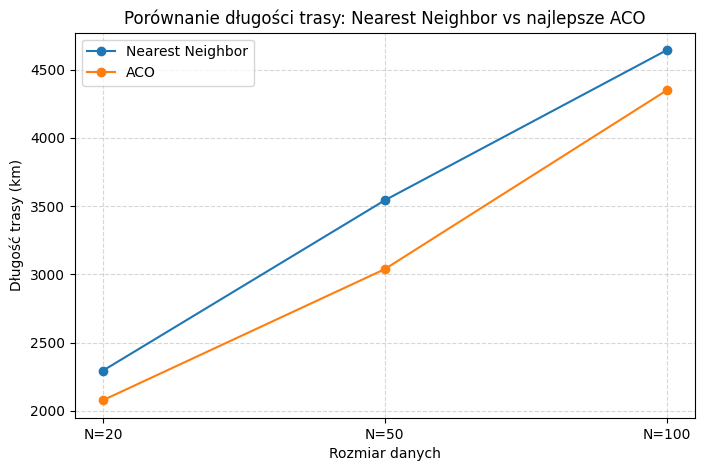

In [13]:
# Wykres porównawczy długości trasy: NN vs najlepsze ACO

plt.figure(figsize=(8, 5))

for alg in final_comparison_df["Algorytm"].unique():
    subset = final_comparison_df[final_comparison_df["Algorytm"] == alg]
    plt.plot(
        subset["Rozmiar danych"],
        subset["Długość trasy (km)"],
        marker="o",
        label=alg
    )

plt.xlabel("Rozmiar danych")
plt.ylabel("Długość trasy (km)")
plt.title("Porównanie długości trasy: Nearest Neighbor vs najlepsze ACO")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

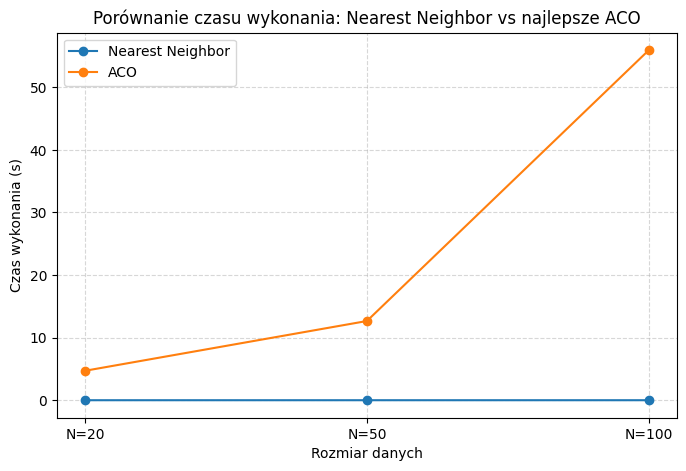

In [14]:
# Wykres porównawczy czasu wykonania: NN vs najlepsze ACO

plt.figure(figsize=(8, 5))

for alg in final_comparison_df["Algorytm"].unique():
    subset = final_comparison_df[final_comparison_df["Algorytm"] == alg]
    plt.plot(
        subset["Rozmiar danych"],
        subset["Czas wykonania (s)"],
        marker="o",
        label=alg
    )

plt.xlabel("Rozmiar danych")
plt.ylabel("Czas wykonania (s)")
plt.title("Porównanie czasu wykonania: Nearest Neighbor vs najlepsze ACO")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### Wizualizacja najlepszych tras po tuningu

In [15]:
# Wczytanie współrzędnych miast potrzebnych do wizualizacji tras
city_datasets = {
    "N=20": pd.read_csv("data/cities_20.csv"),
    "N=50": pd.read_csv("data/cities_50.csv"),
    "N=100": pd.read_csv("data/cities_100.csv"),
}

for ds_name, cities_df in city_datasets.items():
    dist_matrix = datasets[ds_name].to_numpy(dtype=float)
    print(
        ds_name,
        "liczba miast:", len(cities_df),
        "rozmiar macierzy:", dist_matrix.shape
    )

N=20 liczba miast: 20 rozmiar macierzy: (20, 20)
N=50 liczba miast: 50 rozmiar macierzy: (50, 50)
N=100 liczba miast: 100 rozmiar macierzy: (100, 100)


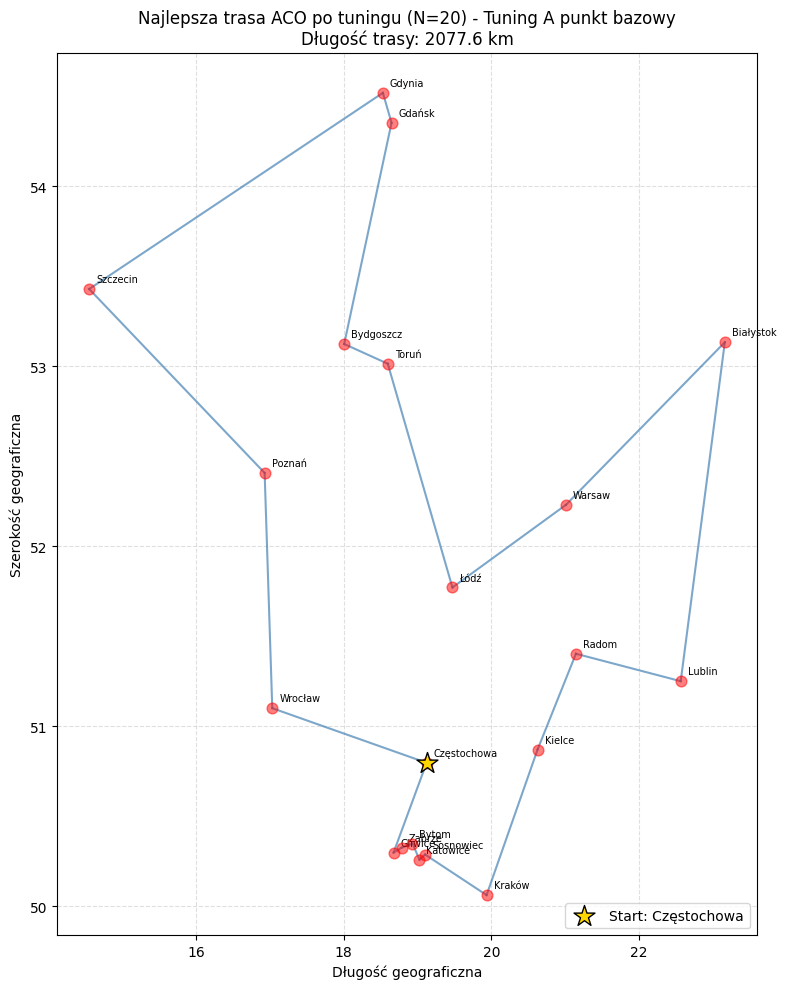

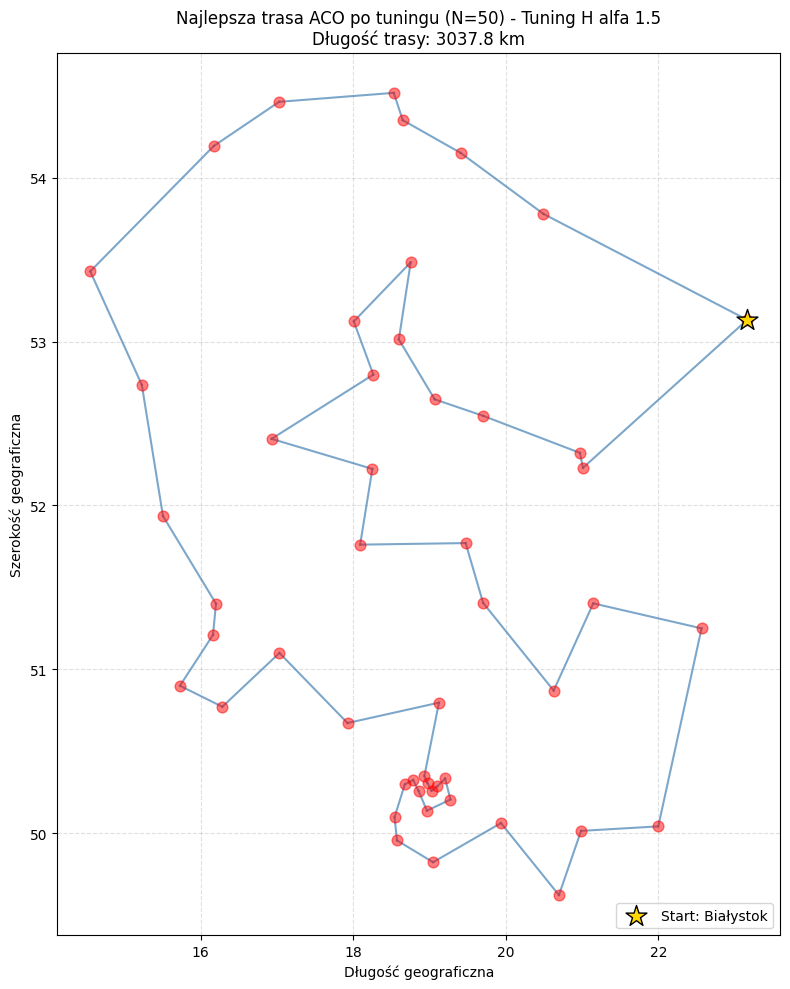

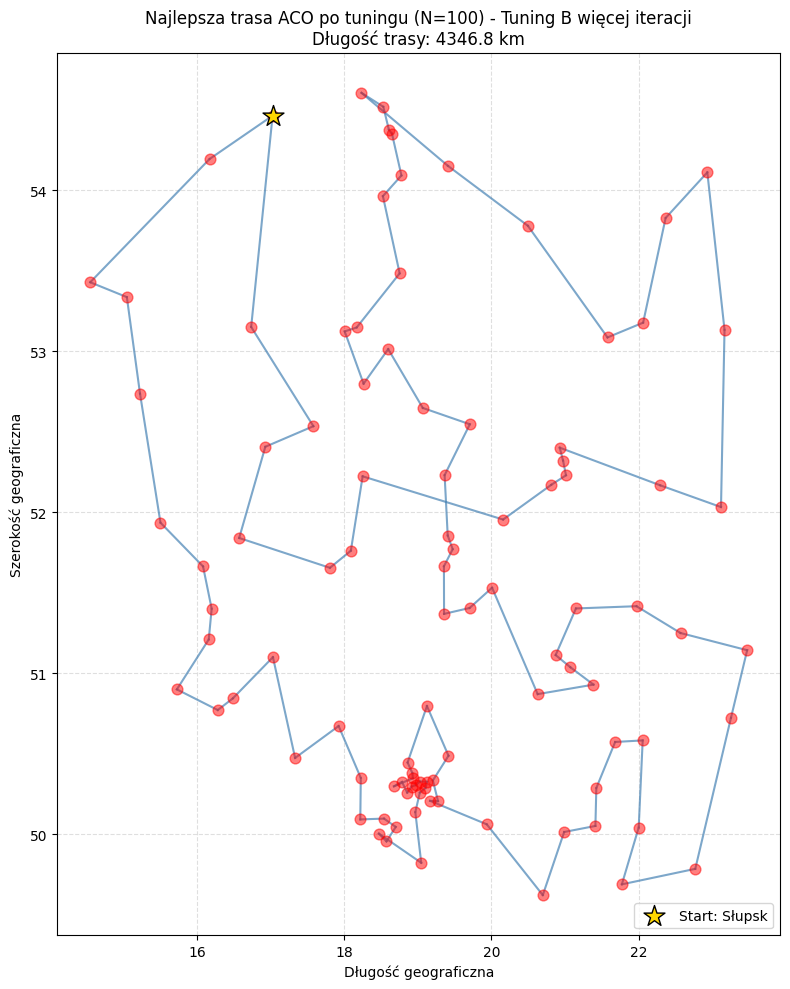

In [16]:
for ds_name in ["N=20", "N=50", "N=100"]:
    dist_matrix = datasets[ds_name].to_numpy(dtype=float)
    best_route = best_tuning_routes[ds_name]

    best_config = final_comparison_df[
        (final_comparison_df["Rozmiar danych"] == ds_name) &
        (final_comparison_df["Algorytm"] == "ACO")
    ]["Konfiguracja"].iloc[0]

    plot_tsp_route(
        city_datasets[ds_name],
        best_route,
        dist_matrix,
        title=f"Najlepsza trasa ACO po tuningu ({ds_name}) - {best_config}"
    )

## Wnioski końcowe

Przeprowadzono eksperymenty dla algorytmu Ant Colony Optimization oraz porównano jego wyniki z metodą Nearest Neighbor. Dla każdego zbioru analizowano długość uzyskanej trasy oraz czas działania algorytmu.

Na początku przeprowadzono eksperyment bazowy z różnymi konfiguracjami ACO. Zmieniano wartości parametrów alfa, beta, rho, liczbę mrówek oraz liczbę iteracji. Wyniki pokazały, że dla najmniejszego zbioru N=20 wiele konfiguracji osiągało taką samą długość trasy. Oznacza to, że problem był stosunkowo prosty i algorytm szybko znajdował bardzo dobre rozwiązanie. W takim przypadku zwiększanie liczby mrówek lub iteracji nie poprawiało jakości wyniku, a jedynie wydłużało czas obliczeń.

Dla większych zbiorów, N=50 i N=100, wpływ hiperparametrów był bardziej widoczny. Różne konfiguracje ACO dawały różne długości tras, co pokazuje, że tuning parametrów ma większe znaczenie wraz ze wzrostem rozmiaru problemu. Największy wpływ na wyniki miały przede wszystkim liczba mrówek, liczba iteracji oraz dobór parametrów beta i rho. Zbyt mała liczba iteracji ograniczała możliwość poprawy rozwiązania, natomiast zbyt duża liczba iteracji zwiększała czas działania bez gwarancji znaczącej poprawy wyniku.

Po eksperymencie bazowym przeprowadzono dokładniejszy tuning wokół najlepiej rokujących konfiguracji. W tej części testowano między innymi wpływ zwiększenia liczby iteracji, liczby mrówek, zmiany beta, rho oraz alfa. Wyniki pokazały, że najlepsza konfiguracja nie jest identyczna dla każdego rozmiaru danych. Dla N=20 większość ustawień osiągała ten sam wynik, natomiast dla N=100 najlepszy rezultat uzyskano przy nieco większym współczynniku parowania rho. Oznacza to, że optymalne parametry ACO zależą od wielkości i charakterystyki danych.

W porównaniu z metodą Nearest Neighbor algorytm ACO uzyskał krótsze trasy dla wszystkich badanych rozmiarów danych. Jako prosta heurystyka zachłanna, Nearest Neighbor działał jednak zdecydowanie szybciej. ACO wymaga znacznie większego czasu obliczeń, ale dzięki losowej eksploracji oraz mechanizmowi feromonów potrafi znaleźć lepsze rozwiązania. Ostatecznie można więc stwierdzić, że ACO oferuje lepszą jakość trasy kosztem dłuższego czasu działania.

Krzywe zbieżności pokazały, że algorytm zwykle poprawia rozwiązanie głównie w początkowych iteracjach, a później zmiany są coraz mniejsze. Jest to typowe zachowanie dla algorytmów metaheurystycznych —  następuje bowiem stabilizacja wyniku i dalsze iteracje nie zawsze przynoszą istotną poprawę. Z tego powodu istotne jest dobranie rozsądnej liczby iteracji, aby uniknąć niepotrzebnego wydłużania obliczeń.

Podsumowując, przeprowadzone eksperymenty potwierdzają, że ACO jest skuteczniejszy jakościowo od Nearest Neighbor w rozwiązywaniu problemu TSP dla badanych danych, ale wymaga odpowiedniego strojenia hiperparametrów. Najważniejszym kompromisem jest relacja między jakością znalezionej trasy a czasem wykonania. W praktyce najlepszym rozwiązaniem jest wybór konfiguracji, która daje istotnie krótszą trasę od nearest neighbor, ale nie powoduje nadmiernego wzrostu czasu obliczeń.